In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

In [2]:
modelname = 'vary p1 v5'

# iepoch=19
iepoch=20

plist = [np.array([.5, .8]),np.array([.55, .8]),np.array([.6, .8]),np.array([.65, .8])]

epoch_size = 33333
n_epoch = 66
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
node=25
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
minlen, maxlen=50,100

In [3]:
# eval collection -------------------
results = []
for ip, p1p2 in enumerate(plist):
    thismodel = f'seed{seed}_{modelname}_p{ip}_ep{iepoch}'
    task = AFR2(spec={'agent':
                      {'lick_cost': env_param[0],
                       'food_reward': env_param[1],
                       'attention_cost_coeff': env_param[2],
                       'attention_cost_temp': env_param[3],
                       'penalty_cost': env_param[4],
                       'iti_cost': env_param[5],
                       'time_in_game_reward': env_param[6]},
                      'experiment': {'no_signal_nodes': node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    model = PPO.load(f'ycstore/{thismodel}', env=taskbelief)

    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                  num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        # for p. vary r.
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))

    for episode in all_episode_data:
        # process
        episode['ip'] = ip
        episode['at_times'] = np.where(
            np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
        episode['at_seq'] = [float(elt[1])
                             for elt in episode['actions']]
        if episode['actions'][-1][0] == 1:
            episode['licktime'] = int(len(episode['states']))
        else:
            episode['lick_licktimetime'] = -1
        episode['trial_len'] = len(episode['actions'])

        results.append(episode)

df = pd.DataFrame(results)

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrap

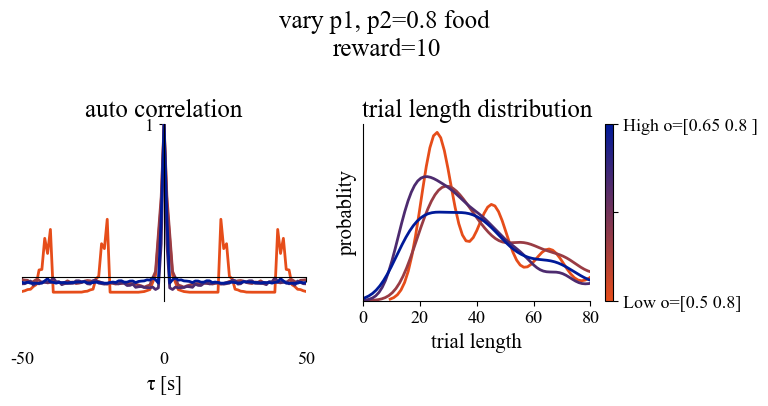

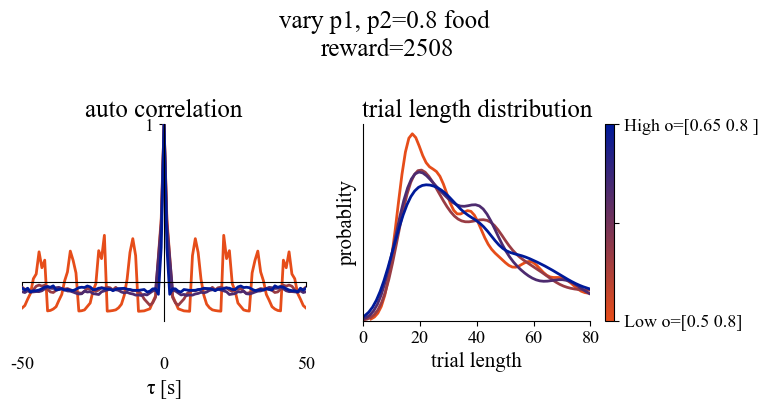

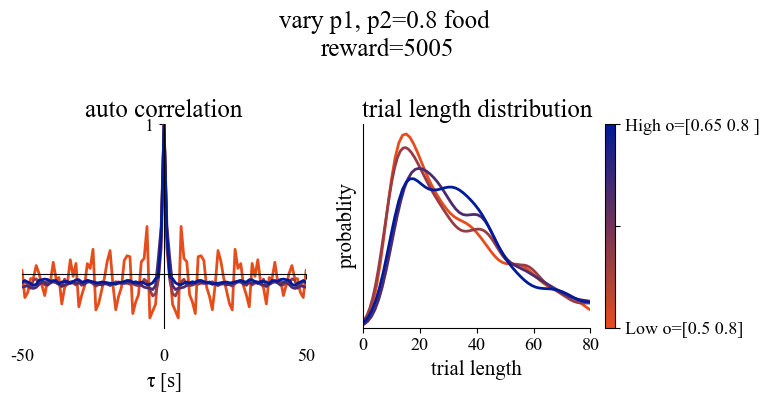

/Users/yc/repo/auditory-foraging-IRC/ult.py:1131: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


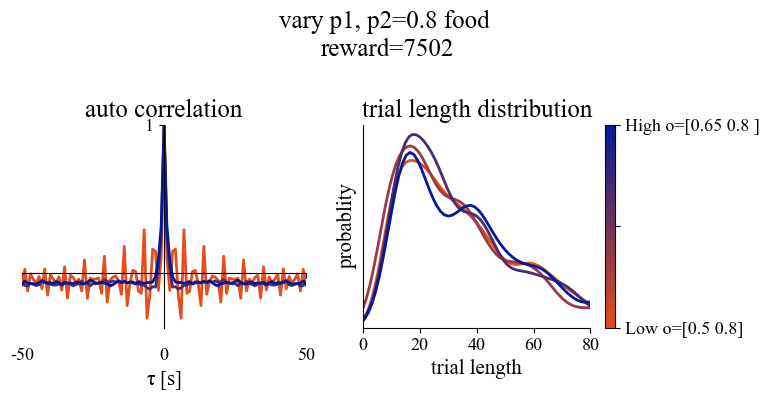

/Users/yc/repo/auditory-foraging-IRC/ult.py:1131: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


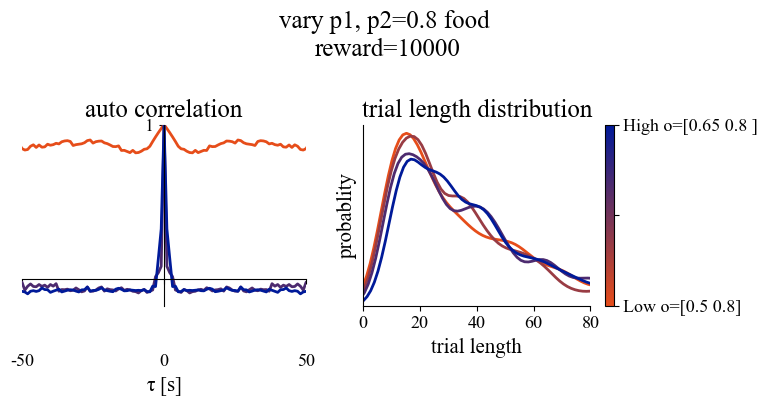

In [4]:
# autocorr
start_rgb = (0.9, 0.3, 0.1) # low reward
end_rgb = (0.0, 0.1, 0.6) # high reward
pcmap = LinearSegmentedColormap.from_list('pcmap', [start_rgb, end_rgb])
# pcmap(np.linspace(0, 1, len(plist)))

for food_reward_idx in range(len(food_reward_list)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) & (df.ip==ip)]
        if len(subdf)==0: 
            print(food_reward_idx, ip, 'skipped')
            continue
        att_seq_list = np.array(subdf.at_seq)
        # print(len(subdf), food_reward_idx, ip)
        autocorr, total_counts = empirical_autocorrelation_new(
            att_seq_list, min_no_samples=1111)
        # print(att_seq_list)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                 label=f'p:{p1p2}', color=pcmap(np.linspace(0, 1, len(plist)))[ip])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=pcmap(np.linspace(0, 1, len(plist)))[ip])
    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50)

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low o={plist[0]}', '', f'High o={plist[-1]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)



    fig.suptitle(
        f'vary p1, p2={p1p2[1]} food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.tight_layout()
    plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_28200/2722842124.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


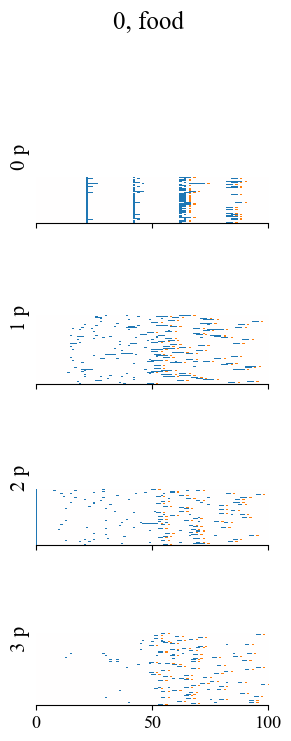

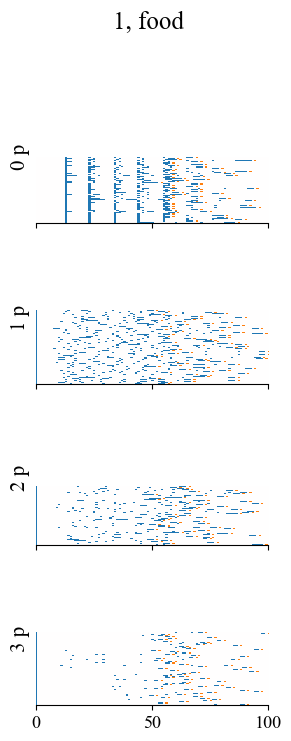

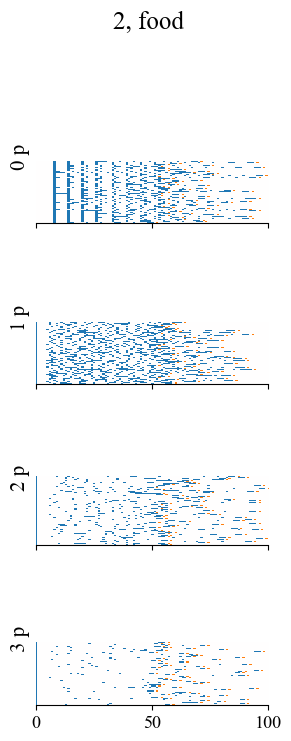

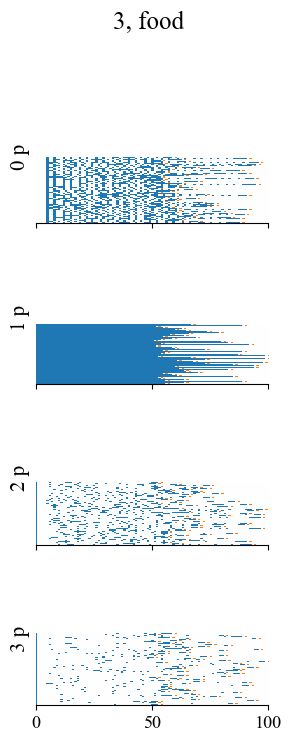

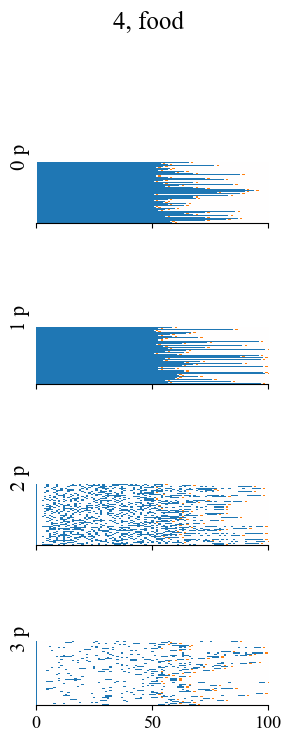

In [5]:
# raster
for food_reward_idx in range(len(food_reward_list)):
    rasterfig, axs = plt.subplots(len(plist), 1, figsize=(
        3, len(plist)*2,), sharex=True, sharey=True)
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) & (df.ip==ip)]

        # df=df[df['at_times'].apply(len) > 0]
        subdf=subdf[subdf.licktime!=-1]
        # df.licktime=df.licktime.astype('int')
        subdf=subdf[~subdf.licktime.isna()]

        if len(subdf)==0: continue
        trial_len = np.array(subdf.trial_len)
        valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
        grid = np.zeros((len(valid_ind), max(trial_len)+2))
        # print(food_reward_idx,ip, grid.shape)
        sortind = np.argsort([trial_len[i] for i in valid_ind])

        # att
        plot_data = np.array(subdf.at_times)[valid_ind]
        for i, arr in enumerate(plot_data):
            grid[i, arr] = -1
        # lick
        plot_data = np.array(subdf.licktime)[valid_ind]
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, int(arr)] = 1


        c = axs[ip].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                           aspect='auto', interpolation='none')

        axs[ip].set_xticks([0, 50, 100])
        axs[ip].set_xlim(0, 100)
        axs[ip].set_ylim(0, 300)
        axs[ip].set_yticks([])
        axs[ip].spines['left'].set_visible(False)
        axs[ip].set_ylabel(f'{ip} p')
    rasterfig.suptitle(f'{food_reward_idx}, food')
    rasterfig.show()

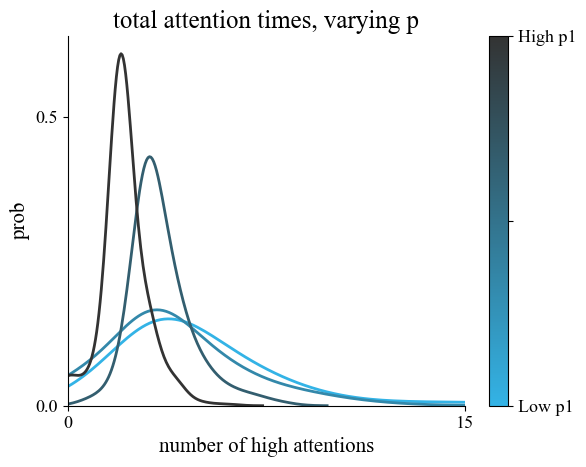

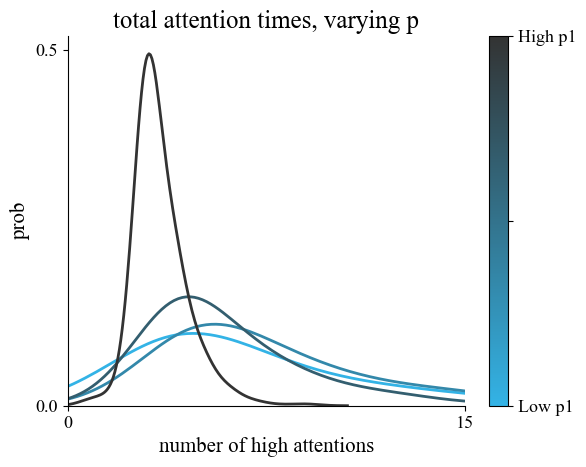

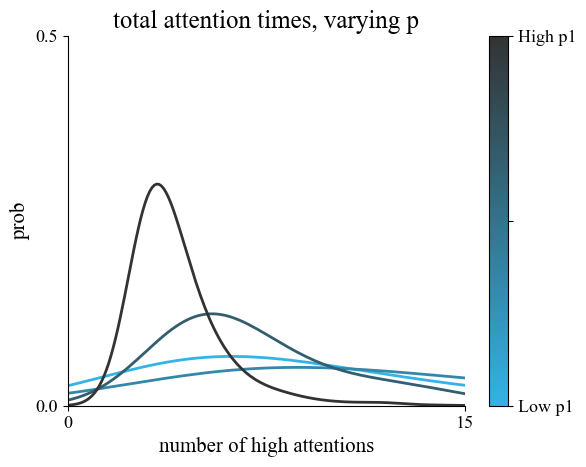

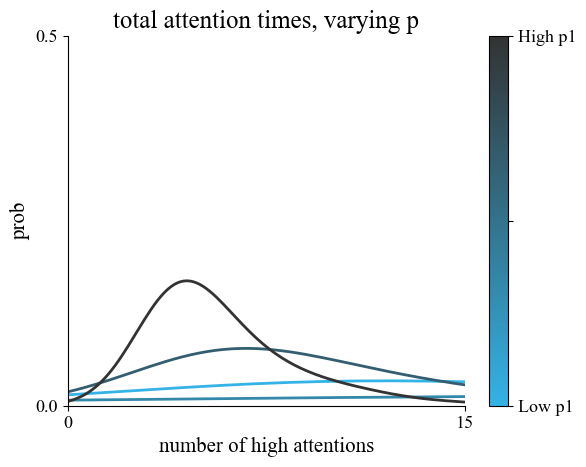

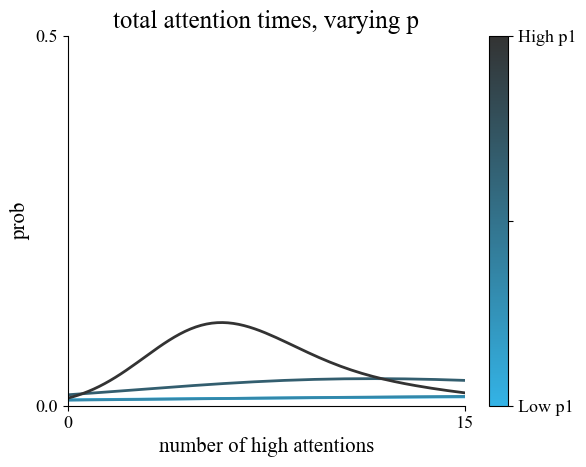

In [15]:
# total attn time dist

for food_reward_idx in np.arange(len(food_reward_list)):
    fig= plt.figure()
    for ip, p1p2 in enumerate(plist[:]):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=pcmap(
            np.linspace(0, 1, len(plist)))[ip])


    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
    ticks = [0, 0.5, 1]
    tick_labels = ['Low p1', '', 'High p1']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    plt.xlabel('number of high attentions')
    plt.ylabel('prob')
    plt.title(f'total attention times, varying p')
    # plt.ylim(0,1500)
    # plt.legend()

    centerax(plt.gca())
    plt.yticks([0,.5])
    plt.xlim(0, 15)
    plt.xticks([0, 15])
    quicksave(f'total att time {food_reward_idx}', 'plot vary p1', fig=fig)
    plt.show()


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


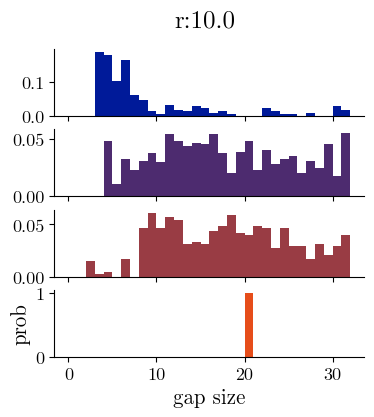

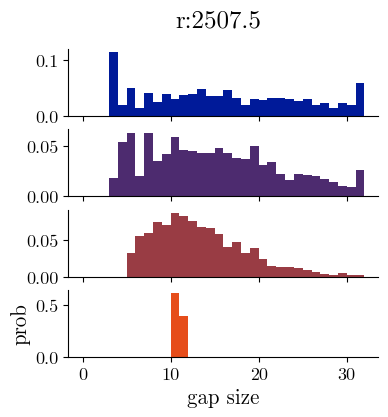

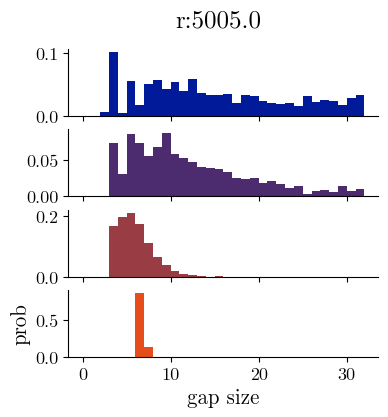

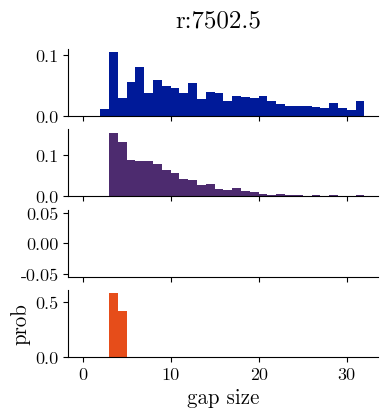

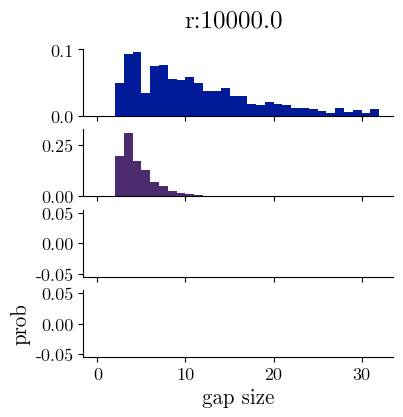

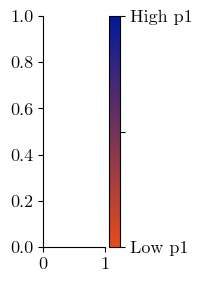

In [ ]:
# att size and gap
for food_reward_idx, reward in enumerate(food_reward_list):
    fig, axs = plt.subplots(len(plist), 1, figsize=(4, 4), sharex=True)
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        gaps=subdf.at_times.apply(find_gaps).to_list()
        gaps=np.concatenate(gaps,)
        axs[len(plist)-ip-1].hist(gaps, bins=np.arange(33), color=pcmap(np.linspace(0, 1, len(plist))[ip]), density=True, alpha=1)
        # sns.kdeplot(gaps, color=pcmap(np.linspace(0, 1, len(plist))[ip]),bw_adjust=2, common_norm=False) 
    plt.suptitle(f'r:{reward}')
    axs[ip].set_xlabel('gap size')
    plt.ylabel('prob')
fig, axs = plt.subplots(1,1, figsize=(1,3))
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low p1', '', 'High p1']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
plt.show()


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


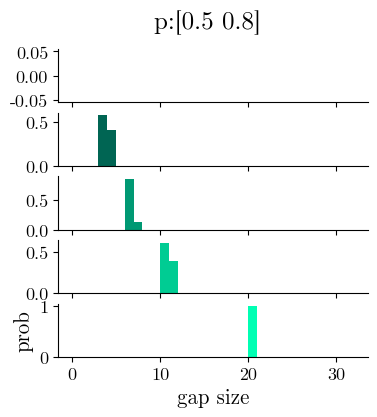

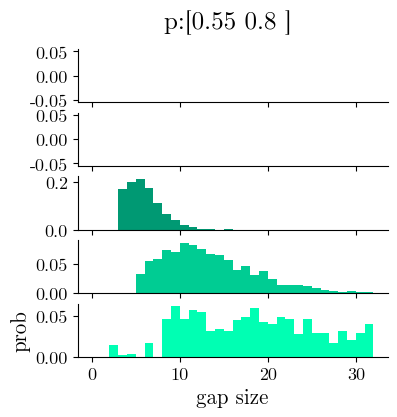

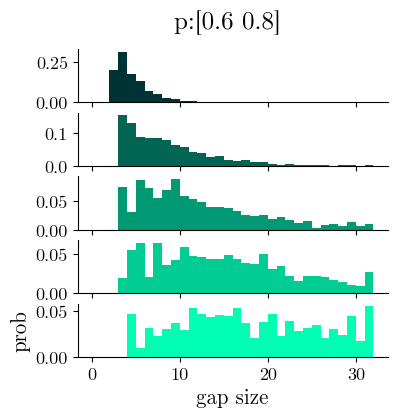

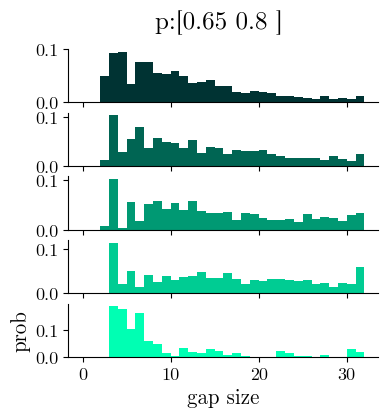

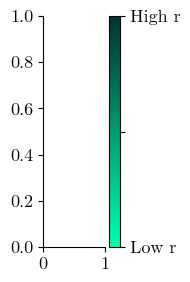

In [ ]:

for ip, p1p2 in enumerate(plist):
    fig, axs = plt.subplots(len(food_reward_list), 1, figsize=(4, 4), sharex=True)
    for food_reward_idx in range(len(food_reward_list)):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        gaps=subdf.at_times.apply(find_gaps).to_list()
        gaps=np.concatenate(gaps,)
        axs[len(food_reward_list)-food_reward_idx-1].hist(gaps, bins=np.arange(33), color=rewardcmap(np.linspace(0, 1, len(food_reward_list))[food_reward_idx]), density=True, alpha=1)
        # sns.kdeplot(gaps, color=rewardcmap(np.linspace(0, 1, len(food_reward_list))[food_reward_idx]),bw_adjust=2, common_norm=False) 
    plt.ylabel('prob')
    plt.suptitle(f'p:{p1p2}')
    plt.xlabel('gap size')
    plt.ylabel('prob')
    plt.show()

fig, axs = plt.subplots(1,1, figsize=(1,3))
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low r', '', 'High r']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_95717/854883283.py:27: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_95717/854883283.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


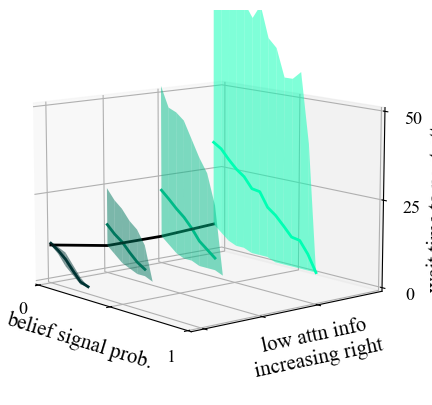

In [ ]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)


for food_reward_idx in [1]:
    plotdata=[] # for plot data
    for ip, p1p2 in enumerate(plist):
        bindata=[[] for _ in range(nbin)] 
        subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.ip==ip)]
        sb, nextatt=[],[]
        for alist, b in zip(subdf.at_times, subdf.beliefs):
            try:
                a,b=trialnextatt(alist,b),trialsb(b)  
                for j in range(len(b)):
                    thisa,thisb=a[j], b[j]
                    for i, (s,e) in enumerate(zip(bins, bins[1:])):
                        if thisa>0 and s<thisb<=e:
                            bindata[i].append(thisa)
            except:
                continue
        
        mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
        mu, err=np.array(mu), np.array(err)
        med=np.array([np.nanmedian(a) for a in bindata])
        percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
        percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
        plotdata.append([percentile_5, percentile_95, mu])

    y_values = np.arange(len(plist))
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    for y, (y1, y2, mu) in zip(y_values, plotdata):
        verts = []
        for i in range(len(bins) - 1):
            verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])
        
        poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(plist)))[len(plist)-y-1], alpha=0.5, edgecolors='none')
        ax.add_collection3d(poly)
        ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(plist)))[len(plist)-y-1])
    mwt=[]
    for thiswt in plotdata:
        thiswt=thiswt[0]
        i=0
        while thiswt[i]==0:
            i+=1
        mwt.append(thiswt[i])
    ax.plot(np.zeros_like(y_values),y_values,mwt ,color='black')

    ax.set_xlim(0, 1)
    # ax.set_ylim(0, 2)
    ax.set_zlim(0, 50)
    ax.set_yticks([0,1,2],[])
    ax.set_zticks([0,25,50])
    ax.set_xticks([0,0.5,1],['0','','1'])
    ax.set_xlabel('belief signal prob.',labelpad=1)
    ax.set_ylabel('low attn info\nincreasing right',labelpad=1)
    ax.set_zlabel('wait time to next attn.',labelpad=1)

    plt.tight_layout()
    ax.view_init(azim=-40, elev=11) 
    quicksave('vary p1 3d large','plot wait time', fig=fig)
    plt.show()



In [ ]:
# # imshow
# vmin,vmax=0,50
# nbin=20
# for food_reward_idx in range(len(food_reward_list)):
#     for ip, p1p2 in enumerate(plist):
#         grid=np.zeros((vmax, nbin))
#         bins=np.linspace(0,1,nbin)
#         bindata=[[] for _ in range(nbin)] 
#         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.ip==ip)]
#         sb, nextatt=[],[]
#         for alist, b in zip(subdf.at_times, subdf.beliefs):
#             try:
#                 a,b=trialnextatt(alist,b),trialsb(b)  
#                 for j in range(len(b)):
#                     thisa,thisb=a[j], b[j]
#                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                         if s<thisb<=e:
#                             bindata[i].append(thisa)
#             except:
#                 continue
#         for i in range(nbin):
#             count=Counter(bindata[i])
#             col=[]
#             for j in range(vmin, vmax):
#                 col.append(count[j])
#             col=np.array(col)
#             col=col/np.sum(col)
#             grid[:,i]=col
#         fig=plt.figure()
#         # grid=np.log(grid)
#         c=plt.imshow(grid,aspect='auto', origin='lower')
#         plt.colorbar(c)
#         plt.xlabel('prob')
#         plt.ylabel('gap')
#         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
#         plt.xticks([0,nbin],[0,1])
#         quicksave(f'vary p large, reward id {food_reward_idx}, p {p1p2}', 'test', fig=fig)
#         # plt.show()
#         plt.close()
# for food_reward_idx in range(len(food_reward_list)):
#     for ip, p1p2 in enumerate(plist):
#         grid=np.zeros((vmax, nbin))
#         bins=np.linspace(0,1,nbin)
#         bindata=[[] for _ in range(nbin)] 
#         subdf=df[(df.trial_food_reward_idx==food_reward_idx)&(df.ip==ip)]
#         sb, nextatt=[],[]
#         for alist, b in zip(subdf.at_times, subdf.beliefs):
#             try:
#                 a,b=trialnextatt(alist,b),trialsb(b)  
#                 for j in range(len(b)):
#                     thisa,thisb=a[j], b[j]
#                     for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                         if s<thisb<=e:
#                             bindata[i].append(thisa)
#             except:
#                 continue
#         for i in range(nbin):
#             count=Counter(bindata[i])
#             col=[]
#             for j in range(vmin, vmax):
#                 col.append(count[j])
#             col=np.array(col)
#             col=col/np.sum(col)
#             grid[:,i]=col
#         fig=plt.figure()
#         grid=np.log(grid)
#         c=plt.imshow(grid,aspect='auto', origin='lower')
#         plt.colorbar(c)
#         plt.xlabel('prob')
#         plt.ylabel('gap')
#         plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{node}')
#         plt.xticks([0,nbin],[0,1])
#         quicksave(f'vary p large, reward id {food_reward_idx}, p {p1p2} log', 'test', fig=fig)
#         # plt.show()
#         plt.close()
